In [150]:
from pathlib import Path
from typing import List, Literal
import librosa
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

import pandas as pd

from config import EMOTIONS, ROOT_DATA_DIR
from prepare_data.info_extractor import AbstractInfoExtractor, CREMADExtractor, RAVDESSExtractor, TESSExtractor

In [151]:
name_to_extractor = {
    # "RAVDESS": RAVDESSExtractor(),
    "TESS": TESSExtractor(),
    # "CREMA-D": CREMADExtractor()
}

In [152]:
def found_files(dataset_dir: Path) -> List[Path]:
    return list(dataset_dir.rglob("*.wav")) # rglob - рекурсивный поиск

def get_info_from_dataset(dataset_name: Literal["RAVDESS", "TESS", "CREMA-D"]):
    dataset_dir = ROOT_DATA_DIR / dataset_name

    extractor: AbstractInfoExtractor = name_to_extractor[dataset_name]

    audio_files = found_files(dataset_dir=dataset_dir)

    dataset_records = []

    for file_path in audio_files:
        try:
            actor_id, emotion_label = extractor.extract_info(file_path)
            actor_id, emotion_label = actor_id.split("_")[1], f"{emotion_label} ({EMOTIONS[emotion_label]})"
            gender = extractor.extract_gender(file_path)

            dataset_records.append({
                "dataset": dataset_name,
                "actor_id": actor_id,
                "emotion_label": emotion_label,
                "gender": gender,
                "file_name": file_path.stem,
                "file_path": str(file_path),
            })
        except (ValueError, KeyError, IndexError) as e:
            print(f"Ошибка в обработке файла {file_path}: {e}. Пропуск...")
            continue
    
    df = pd.DataFrame(dataset_records)
    print(f"[{dataset_name}] В таблицу добавлено {len(df)} файлов.")
    return df


datasets = name_to_extractor.keys()

all_dfs = []
for ds in datasets:
    df = get_info_from_dataset(dataset_name=ds)
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nВсего собрано аудиофайлов для анализа: {len(final_df)}")

pivot_table = pd.crosstab(
    index=final_df['emotion_label'], 
    columns=[final_df['dataset'], final_df['gender']], 
    margins=True,
    margins_name="ИТОГО"
)

print("\nСводная таблица распределения классов:")
print(pivot_table)
final_df.to_csv("dataset_analysis.csv", index=False)
pivot_table.to_csv("dataset_statistics.csv", index=False)


Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_pole_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_dime_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_nice_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_cab_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_join_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_sour_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_dip_ps.wav: 'ps'. Пропуск...
Ошибка в обработке файла /home/gealor/neural_network/dataset/TESS/YAF_pleasant_surprised/YAF_rot_ps.wav: 'ps'. Пропуск...
Ошибка в обработке 

In [153]:
def extract_mel_energy(file_path: str) -> float:
    """Извлекает среднюю энергию низких частот (1-20 Мел-полос) из спектрограммы."""
    try:
        y, sr = librosa.load(file_path, sr=16000, duration=3.0)
        y, _ = librosa.effects.trim(y, top_db=25)

        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Усреднение по оси времени, берем первые 20 мел-полос (нижние частоты)
        mean_mel_across_time = np.mean(mel_spec_db, axis=1) # для каждой строки вычисляется среднее
        low_freq_energy = np.mean(mean_mel_across_time[:20]) # анализируем только низкие частоты, чтобы анализировать больше полезной информации
        # т.к. в высоких частотах зачастую пустота (черные области)
        # low_freq_energy = np.mean(mean_mel_across_time) # анализируем всю спектрограмму
        return float(low_freq_energy)
    except Exception:
        return np.nan
    
def prepare_statistical_data(final_df: pd.DataFrame, n_samples: int | None = 150):
    """
    Выполняет подготовку данных для статистического анализа: 
    выборку и извлечение спектральных признаков.
    """
    print("Формирование выборки и извлечение признаков (пожалуйста, подождите)...")
    
    # 1. Сэмплирование
    if n_samples is not None:
        sampled_df = final_df.groupby('emotion_label').sample(n=n_samples, random_state=42)
    else:
        sampled_df = final_df.copy()
    
    # 2. Извлечение энергии
    sampled_df['low_freq_energy'] = sampled_df['file_path'].apply(extract_mel_energy)
    
    # 3. Очистка
    return sampled_df.dropna(subset=['low_freq_energy'])

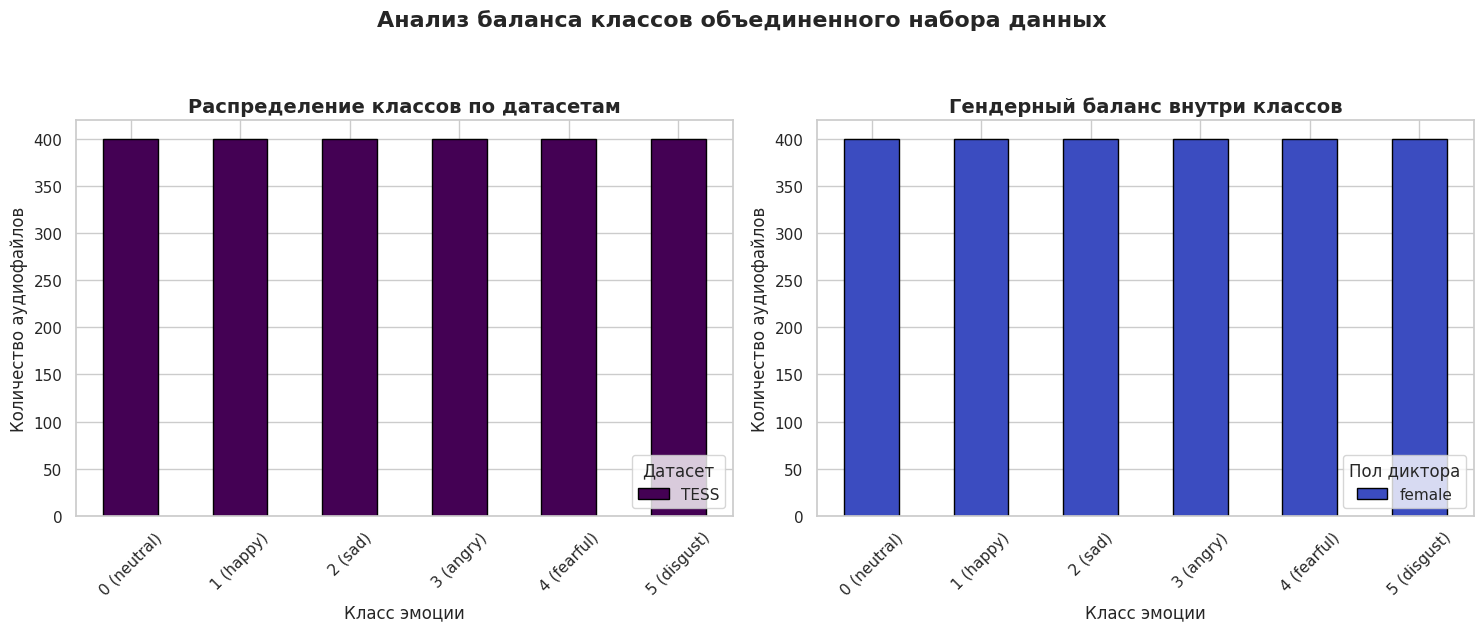

Формирование выборки и извлечение признаков (пожалуйста, подождите)...


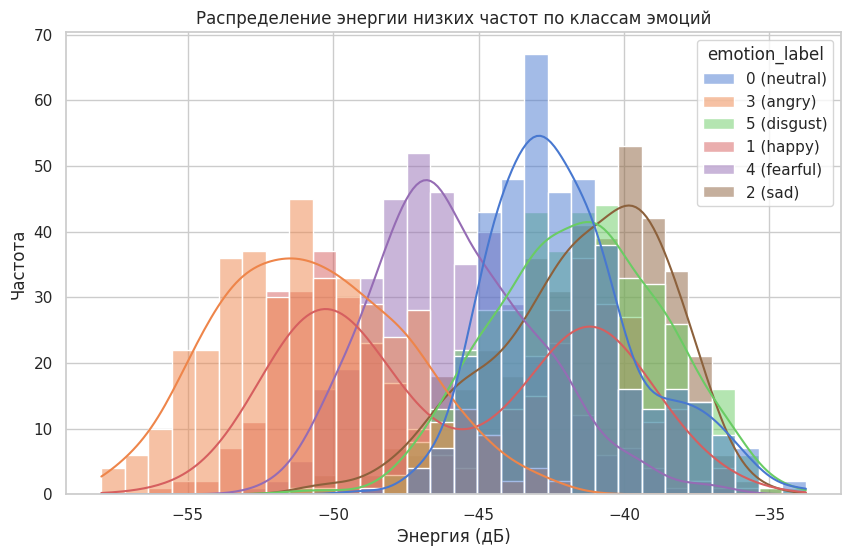

In [154]:
def visualize_graph(final_df: pd.DataFrame):
    sns.set_theme(style="whitegrid", palette="muted")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    # Разбивка по Датасетам
    dataset_counts = final_df.groupby(['emotion_label', 'dataset']).size().reset_index(name='count')
    dataset_pivot = dataset_counts.pivot(index='emotion_label', columns='dataset', values='count')
    dataset_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', edgecolor='black')

    axes[0].set_title('Распределение классов по датасетам', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Класс эмоции', fontsize=12)
    axes[0].set_ylabel('Количество аудиофайлов', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Датасет', loc="lower right")

    # Разбивка по Полу
    gender_counts = final_df.groupby(['emotion_label', 'gender']).size().reset_index(name='count')
    gender_pivot = gender_counts.pivot(index='emotion_label', columns='gender', values='count')
    gender_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='coolwarm', edgecolor='black')

    axes[1].set_title('Гендерный баланс внутри классов', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Класс эмоции', fontsize=12)
    axes[1].set_ylabel('Количество аудиофайлов', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Пол диктора', loc="lower right")

    # Общий заголовок и компановка
    plt.suptitle('Анализ баланса классов объединенного набора данных', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()

    plt.savefig("class_balance_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_distribution(sampled_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    # Гистограмма + кривая распределения (KDE)
    sns.histplot(data=sampled_df, x='low_freq_energy', hue='emotion_label', kde=True, bins=30)
    plt.title('Распределение энергии низких частот по классам эмоций')
    plt.xlabel('Энергия (дБ)')
    plt.ylabel('Частота')
    plt.show()


visualize_graph(final_df)
sampled_df = prepare_statistical_data(
    final_df, 
    n_samples=None
)
plot_distribution(sampled_df)


=== Статистический анализ спектрограмм (ANOVA) ===

--- Точные значения энергии по классам (дБ) ---
0 (neutral)          | Среднее: -42.03 дБ | Медиана: -42.42 дБ
1 (happy)            | Среднее: -45.86 дБ | Медиана: -46.93 дБ
2 (sad)              | Среднее: -41.47 дБ | Медиана: -41.13 дБ
3 (angry)            | Среднее: -50.73 дБ | Медиана: -50.94 дБ
4 (fearful)          | Среднее: -45.83 дБ | Медиана: -46.21 дБ
5 (disgust)          | Среднее: -41.59 дБ | Медиана: -41.41 дБ
-----------------------------------------------

F-статистика: 488.64
P-значение (p-value): 0.00000e+00
ВЫВОД: Отвергаем H0. Фактор 'Эмоция' СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на энергию спектрограммы.


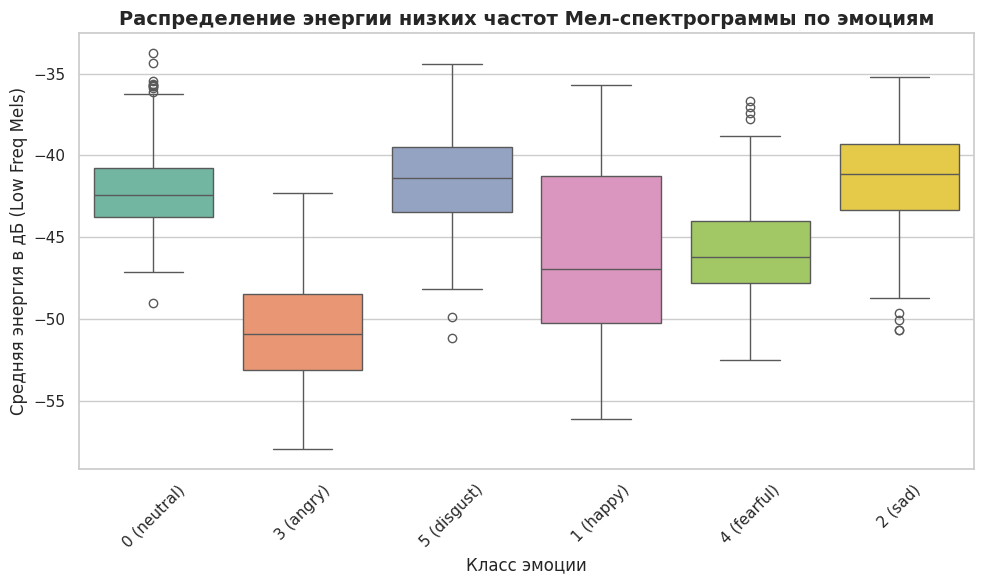

In [155]:
def perform_anova(sampled_df: pd.DataFrame):
    print("\n=== Статистический анализ спектрограмм (ANOVA) ===")
    
    print("\n--- Точные значения энергии по классам (дБ) ---")
    # Группируем данные и считаем среднее (mean) и медиану (median)
    summary_stats = sampled_df.groupby('emotion_label')['low_freq_energy'].agg(['mean', 'median']).reset_index()
    
    for index, row in summary_stats.iterrows():
        print(f"{row['emotion_label']:20} | Среднее: {row['mean']:.2f} дБ | Медиана: {row['median']:.2f} дБ")
    print("-----------------------------------------------\n")

    # Подготавливаем списки значений для каждой группы (эмоции)
    groups = [group['low_freq_energy'].values for name, group in sampled_df.groupby('emotion_label')]

    # Проводим One-Way ANOVA (F-тест)
    f_statistic, p_value = stats.f_oneway(*groups)

    print(f"F-статистика: {f_statistic:.2f}")
    print(f"P-значение (p-value): {p_value:.5e}")

    if p_value < 0.05:
        print("ВЫВОД: Отвергаем H0. Фактор 'Эмоция' СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на энергию спектрограммы.")
    else:
        print("ВЫВОД: Нет оснований отвергнуть H0.")

    # Рисуем Boxplot (Ящик с усами)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='emotion_label', y='low_freq_energy', data=sampled_df, palette='Set2', hue='emotion_label', legend=False)
    plt.title('Распределение энергии низких частот Мел-спектрограммы по эмоциям', fontsize=14, fontweight='bold')
    plt.ylabel('Средняя энергия в дБ (Low Freq Mels)', fontsize=12)
    plt.xlabel('Класс эмоции', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Сохраняем график
    plt.savefig("anova_spectrogram_boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()

perform_anova(sampled_df)

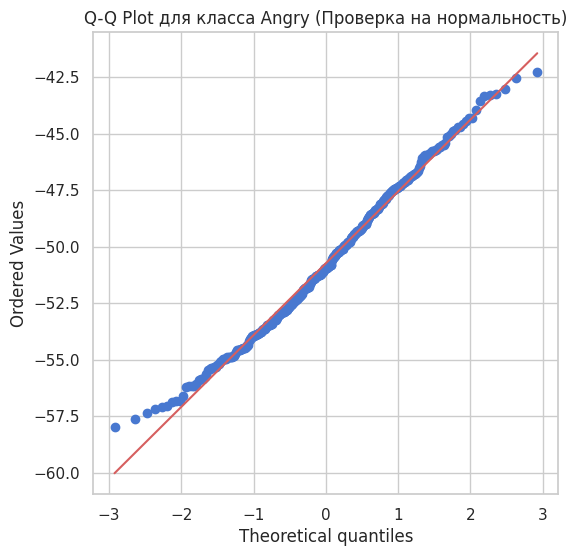


=== Непараметрический критерий (Краскела-Уоллиса) ===
H-статистика: 1126.79
P-value: 2.11336e-241
ВЫВОД: Распределения значимо различаются (непараметрический тест подтвердил).


In [156]:
def check_statistics(sampled_df):
    # 1. Проверка на нормальность (Q-Q Plot для класса Angry)
    plt.figure(figsize=(6, 6))
    angry_data = sampled_df[sampled_df['emotion_label'].str.contains('angry')]['low_freq_energy']
    stats.probplot(angry_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot для класса Angry (Проверка на нормальность)')
    plt.show()

    # 2. Непараметрический критерий Краскела-Уоллиса
    groups =[group['low_freq_energy'].values for name, group in sampled_df.groupby('emotion_label')]
    h_stat, p_val = stats.kruskal(*groups)
    
    print(f"\n=== Непараметрический критерий (Краскела-Уоллиса) ===")
    print(f"H-статистика: {h_stat:.2f}")
    print(f"P-value: {p_val:.5e}")
    if p_val < 0.05:
        print("ВЫВОД: Распределения значимо различаются (непараметрический тест подтвердил).")

check_statistics(sampled_df)